In [ ]:
!pip install tensorflow

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

# Read the Excel file
# Replace 'your_file.xlsx' with your actual Excel file name
df = pd.read_excel('/content/drive/MyDrive/SOP_Twin/corrected_data.xlsx')

# Get all column names
columns = df.columns.tolist()

# Separate voltage and current columns
voltage_columns = columns[::2]  # Every even indexed column (0, 2, 4, ...)
current_columns = columns[1::2]  # Every odd indexed column (1, 3, 5, ...)

# Create new dataframe with renamed columns
new_df = pd.DataFrame()

# Add voltage columns with renamed headers
for i, col in enumerate(voltage_columns):
    new_df[f'Voltage_{i+1}'] = df[col]



# Display first few rows of the new dataframe
print(new_df.head())

   Voltage_1  Voltage_2  Voltage_3  Voltage_4  Voltage_5  Voltage_6  \
0  -0.000054  -0.000061  -0.000061  -0.000072  -0.000095  -0.000095   
1  -0.000127  -0.000140  -0.000140  -0.000170  -0.000222  -0.000222   
2  -0.000200  -0.000218  -0.000218  -0.000268  -0.000347  -0.000347   
3  -0.000271  -0.000295  -0.000295  -0.000364  -0.000471  -0.000471   
4  -0.000342  -0.000372  -0.000372  -0.000459  -0.000594  -0.000594   

   Voltage_7  Voltage_8  Voltage_9  Voltage_10  ...  Voltage_23  Voltage_24  \
0  -0.000065  -0.000049  -0.000048   -0.000059  ...   -0.000060   -0.000060   
1  -0.000144  -0.000108  -0.000107   -0.000133  ...   -0.000132   -0.000132   
2  -0.000222  -0.000166  -0.000166   -0.000206  ...   -0.000204   -0.000204   
3  -0.000299  -0.000224  -0.000223   -0.000278  ...   -0.000275   -0.000275   
4  -0.000375  -0.000281  -0.000280   -0.000350  ...   -0.000345   -0.000345   

   Voltage_25  Voltage_26  Voltage_27  Voltage_28  Voltage_29  Voltage_30  \
0   -0.000046   -0.00

In [ ]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler

def prepare_sequences(df, n_steps=100):
    """
    Prepare sequences for time series prediction

    Args:
        df: DataFrame with voltage columns
        n_steps: Number of time steps to use for prediction

    Returns:
        X: Input sequences with shape (samples, time_steps, features)
        series_ids: Series identifiers for each sequence
        y: Target values
    """
    X, series_ids, y = [], [], []
    voltage_cols = [col for col in df.columns if 'Voltage_' in col]

    for series_idx, col in enumerate(voltage_cols):
        series_data = df[col].values

        # Create sequences for this series
        for j in range(len(series_data) - n_steps):
            X.append(series_data[j:j+n_steps])
            series_ids.append(series_idx)
            y.append(series_data[j+n_steps])

    return np.array(X), np.array(series_ids), np.array(y)

# Parameters
n_steps = 100  # Number of time steps in each sequence
test_size = 0.2  # Percentage of data to use for testing

# Prepare sequences
X, series_ids, y = prepare_sequences(new_df, n_steps)
X = X.reshape((X.shape[0], X.shape[1], 1))  # Reshape for LSTM (samples, timesteps, features)

# Create train-test split - IMPORTANT: For time series, we shouldn't shuffle!
# Split by series to keep temporal order
unique_series = np.unique(series_ids)
train_series = unique_series[:int(len(unique_series)*(1-test_size))]
test_series = unique_series[int(len(unique_series)*(1-test_size)):]

train_mask = np.isin(series_ids, train_series)
test_mask = np.isin(series_ids, test_series)

X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]
series_ids_train, series_ids_test = series_ids[train_mask], series_ids[test_mask]

# Scale data - scale each series individually
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

# For training data
X_train_scaled = np.zeros_like(X_train)
y_train_scaled = np.zeros_like(y_train)

for series_id in train_series:
    mask = (series_ids_train == series_id)
    # Scale X
    X_train_scaled[mask] = scaler_X.fit_transform(X_train[mask].reshape(-1, 1)).reshape(X_train[mask].shape)
    # Scale y
    y_train_scaled[mask] = scaler_y.fit_transform(y_train[mask].reshape(-1, 1)).flatten()

# For test data (use the same scalers from training)
X_test_scaled = np.zeros_like(X_test)
y_test_scaled = np.zeros_like(y_test)

for series_id in test_series:
    mask = (series_ids_test == series_id)
    # Scale X
    X_test_scaled[mask] = scaler_X.transform(X_test[mask].reshape(-1, 1)).reshape(X_test[mask].shape)
    # Scale y
    y_test_scaled[mask] = scaler_y.transform(y_test[mask].reshape(-1, 1)).flatten()

print(f"Training shapes - X: {X_train_scaled.shape}, y: {y_train_scaled.shape}")
print(f"Test shapes - X: {X_test_scaled.shape}, y: {y_test_scaled.shape}")

Training shapes - X: (247500, 100, 1), y: (247500,)
Test shapes - X: (69300, 100, 1), y: (69300,)


Original Target Data Range: [0.390, 45.925]
Scaled Target Data Range: [-0.003, 0.840]


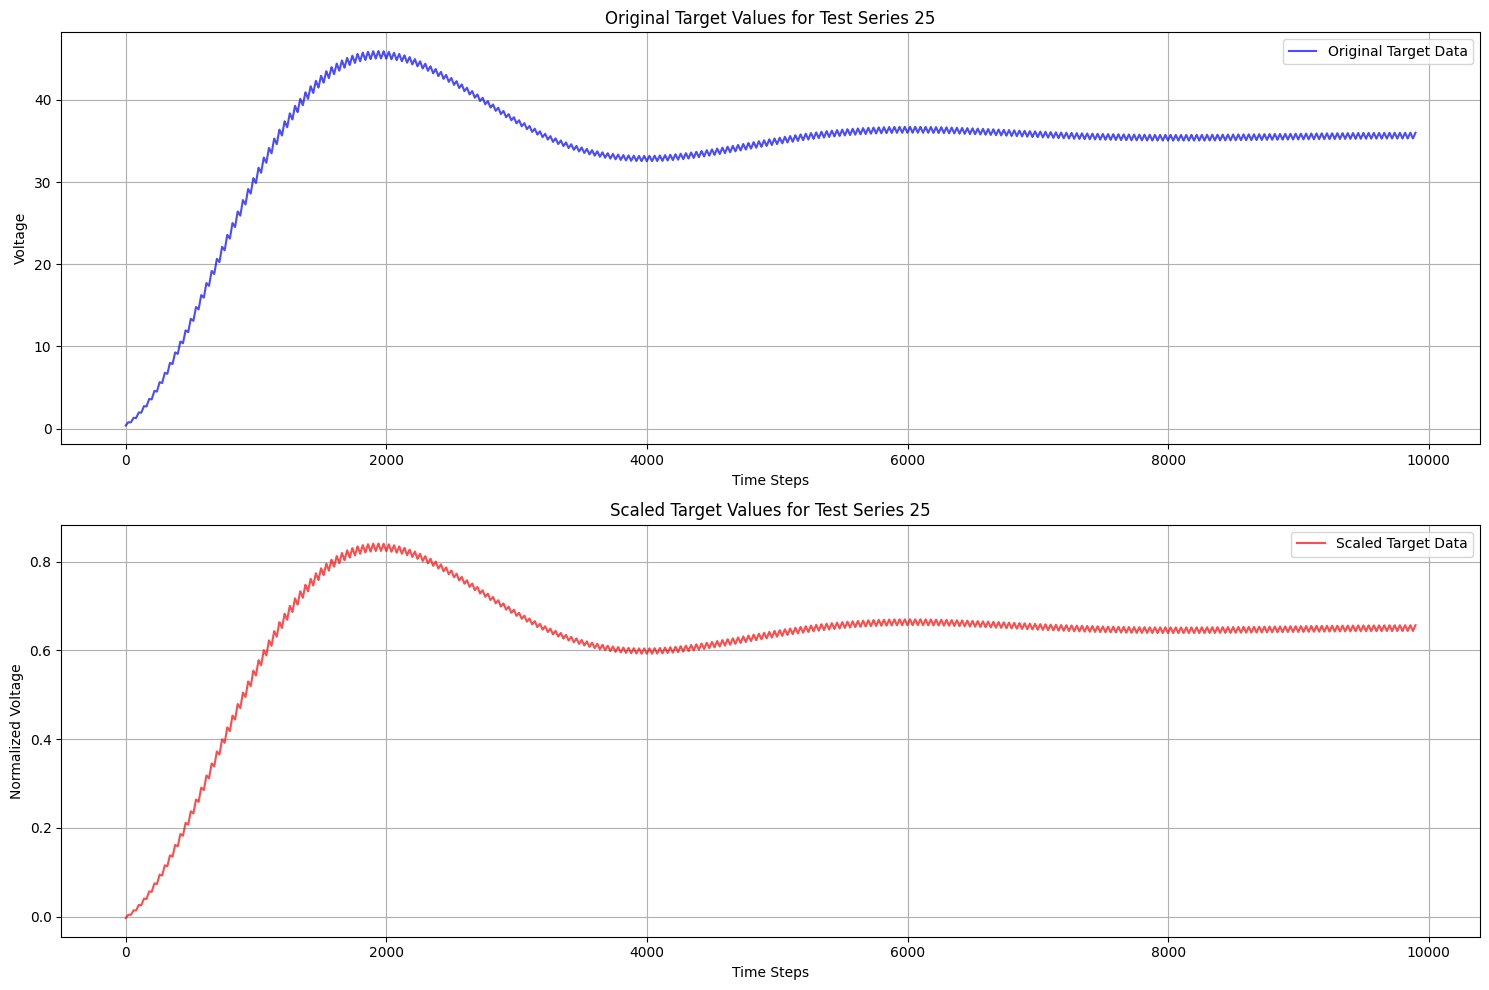

In [ ]:
# Select a series ID from test_series
import matplotlib.pyplot as plt

series_id = test_series[0]  # Taking first test series

# Get masks for this series
test_mask_series = (series_ids_test == series_id)

# Get original and scaled target values
original_y = y_test[test_mask_series]
scaled_y = y_test_scaled[test_mask_series]

# Create subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10))

# Plot original target data
ax1.plot(original_y, label='Original Target Data', color='blue', alpha=0.7)
ax1.set_title(f'Original Target Values for Test Series {series_id}')
ax1.set_xlabel('Time Steps')
ax1.set_ylabel('Voltage')
ax1.grid(True)
ax1.legend()

# Plot scaled target data
ax2.plot(scaled_y, label='Scaled Target Data', color='red', alpha=0.7)
ax2.set_title(f'Scaled Target Values for Test Series {series_id}')
ax2.set_xlabel('Time Steps')
ax2.set_ylabel('Normalized Voltage')
ax2.grid(True)
ax2.legend()

# Adjust layout to prevent overlap
plt.tight_layout()

# Print statistics
print(f"Original Target Data Range: [{original_y.min():.3f}, {original_y.max():.3f}]")
print(f"Scaled Target Data Range: [{scaled_y.min():.3f}, {scaled_y.max():.3f}]")

plt.show()

In [ ]:
def build_pooled_model(n_steps, n_features, n_series):
    """
    Build a pooled neural network model with series identifiers

    Args:
        n_steps: Number of time steps in input sequences
        n_features: Number of features per time step
        n_series: Number of unique series (voltage columns)

    Returns:
        model: Compiled Keras model
    """
    # Input layers
    time_series_input = Input(shape=(n_steps, n_features), name='time_series_input')
    series_id_input = Input(shape=(1,), name='series_id_input')

    # Embed the series identifier
    embedding_dim = min(5, (n_series + 1) // 2)  # Rule of thumb for embedding dimension
    series_embedding = Embedding(input_dim=n_series, output_dim=embedding_dim)(series_id_input)
    series_embedding = Dense(embedding_dim)(series_embedding)
    series_embedding = Dropout(0.2)(series_embedding)

    # Process time series with LSTM
    lstm_out = LSTM(50, return_sequences=False)(time_series_input)
    lstm_out = Dropout(0.2)(lstm_out)

    # Flatten embedding before concatenation
    series_embedding_flat = Dense(embedding_dim, activation='relu')(series_embedding[:, 0, :])

    # Combine features
    concatenated = Concatenate()([lstm_out, series_embedding_flat])

    # Output layer
    output = Dense(1)(concatenated)

    # Define model
    model = Model(inputs=[time_series_input, series_id_input], outputs=output)

    # Compile model
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])

    return model

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Embedding, Concatenate, Dropout
n_steps = 100  # Number of time steps to use for prediction
n_features = 1  # Each sequence contains one feature (the voltage value)

Epoch 1/5
6188/6188 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0079 - mae: 0.0482

6188/6188 ━━━━━━━━━━━━━━━━━━━━ 265s 42ms/step - loss: 0.0079 - mae: 0.0482 - val_loss: 2.5368e-05 - val_mae: 0.0040
Epoch 2/5
6188/6188 ━━━━━━━━━━━━━━━━━━━━ 262s 42ms/step - loss: 3.2490e-04 - mae: 0.0114 - val_loss: 2.0666e-04 - val_mae: 0.0137
Epoch 3/5
6188/6188 ━━━━━━━━━━━━━━━━━━━━ 261s 42ms/step - loss: 2.8391e-04 - mae: 0.0104 - val_loss: 1.3642e-04 - val_mae: 0.0074
Epoch 4/5
6187/6188 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 2.6704e-04 - mae: 0.0099

6188/6188 ━━━━━━━━━━━━━━━━━━━━ 263s 42ms/step - loss: 2.6704e-04 - mae: 0.0099 - val_loss: 1.5503e-05 - val_mae: 0.0035
Epoch 5/5
6188/6188 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 2.5063e-04 - mae: 0.0095

6188/6188 ━━━━━━━━━━━━━━━━━━━━ 321s 42ms/step - loss: 2.5063e-04 - mae: 0.0095 - val_loss: 6.5193e-06 - val_mae: 0.0020

Test Loss (MSE): 0.0000
Test MAE: 0.0031
2166/2166 ━━━━━━━━━━━━━━━━━━━━ 30s 14ms/step


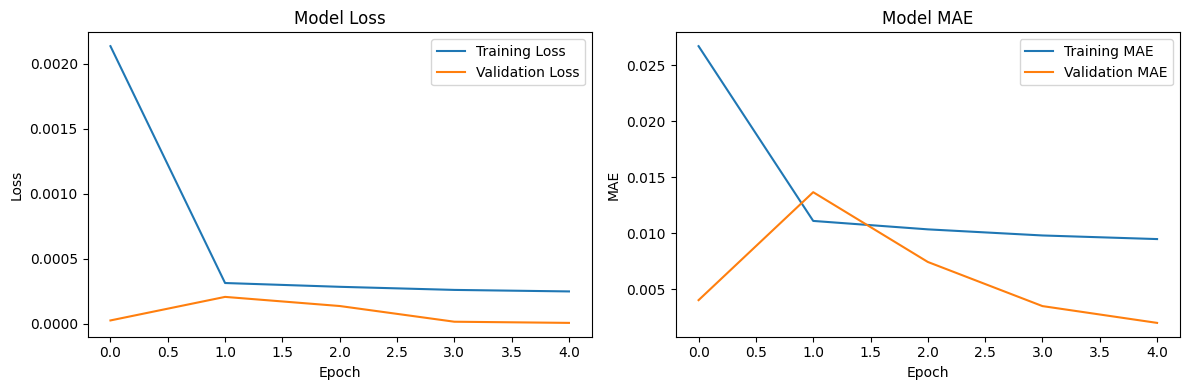

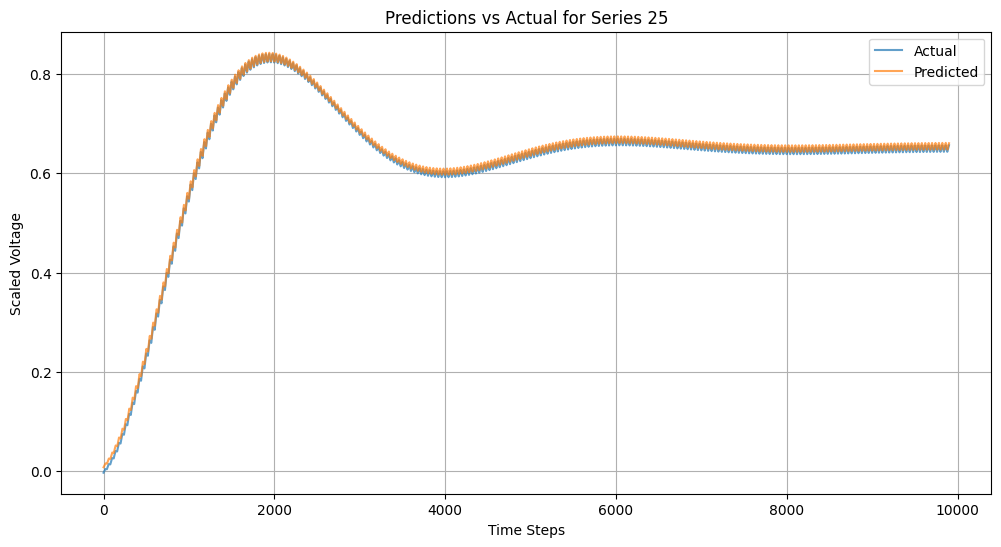

In [ ]:
# Import required libraries
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Embedding, Concatenate, Dropout
import numpy as np
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Get dimensions for model
n_steps = 100
n_features = 1
n_series = len(np.unique(series_ids))

# Build the model using the function you defined
model = build_pooled_model(n_steps, n_features, n_series)

# Prepare inputs for training
train_series_ids = series_ids_train.reshape(-1, 1)
test_series_ids = series_ids_test.reshape(-1, 1)

# Define callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

model_checkpoint = ModelCheckpoint(
    'best_model.h5',
    monitor='val_loss',
    save_best_only=True
)

# Train the model
history = model.fit(
    [X_train_scaled, train_series_ids],  # Input data
    y_train_scaled,                       # Target data
    epochs=5,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping, model_checkpoint],
    verbose=1
)

# Evaluate the model
test_loss = model.evaluate(
    [X_test_scaled, test_series_ids],
    y_test_scaled,
    verbose=0
)

print(f'\nTest Loss (MSE): {test_loss[0]:.4f}')
print(f'Test MAE: {test_loss[1]:.4f}')

# Make predictions
y_pred_scaled = model.predict([X_test_scaled, test_series_ids])

# Visualize training history
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.title('Model MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()

plt.tight_layout()
plt.show()

# Plot predictions vs actual for one series
test_series_id = test_series[0]
series_mask = (series_ids_test == test_series_id)

plt.figure(figsize=(12, 6))
plt.plot(y_test_scaled[series_mask], label='Actual', alpha=0.7)
plt.plot(y_pred_scaled[series_mask], label='Predicted', alpha=0.7)
plt.title(f'Predictions vs Actual for Series {test_series_id}')
plt.xlabel('Time Steps')
plt.ylabel('Scaled Voltage')
plt.legend()
plt.grid(True)
plt.show()

Scaled Values Range:
Actual: [-0.003, 0.840]
Predicted: [0.008, 0.843]

Original Values Range:
Actual: [0.390, 45.925]
Predicted: [0.984, 46.069]


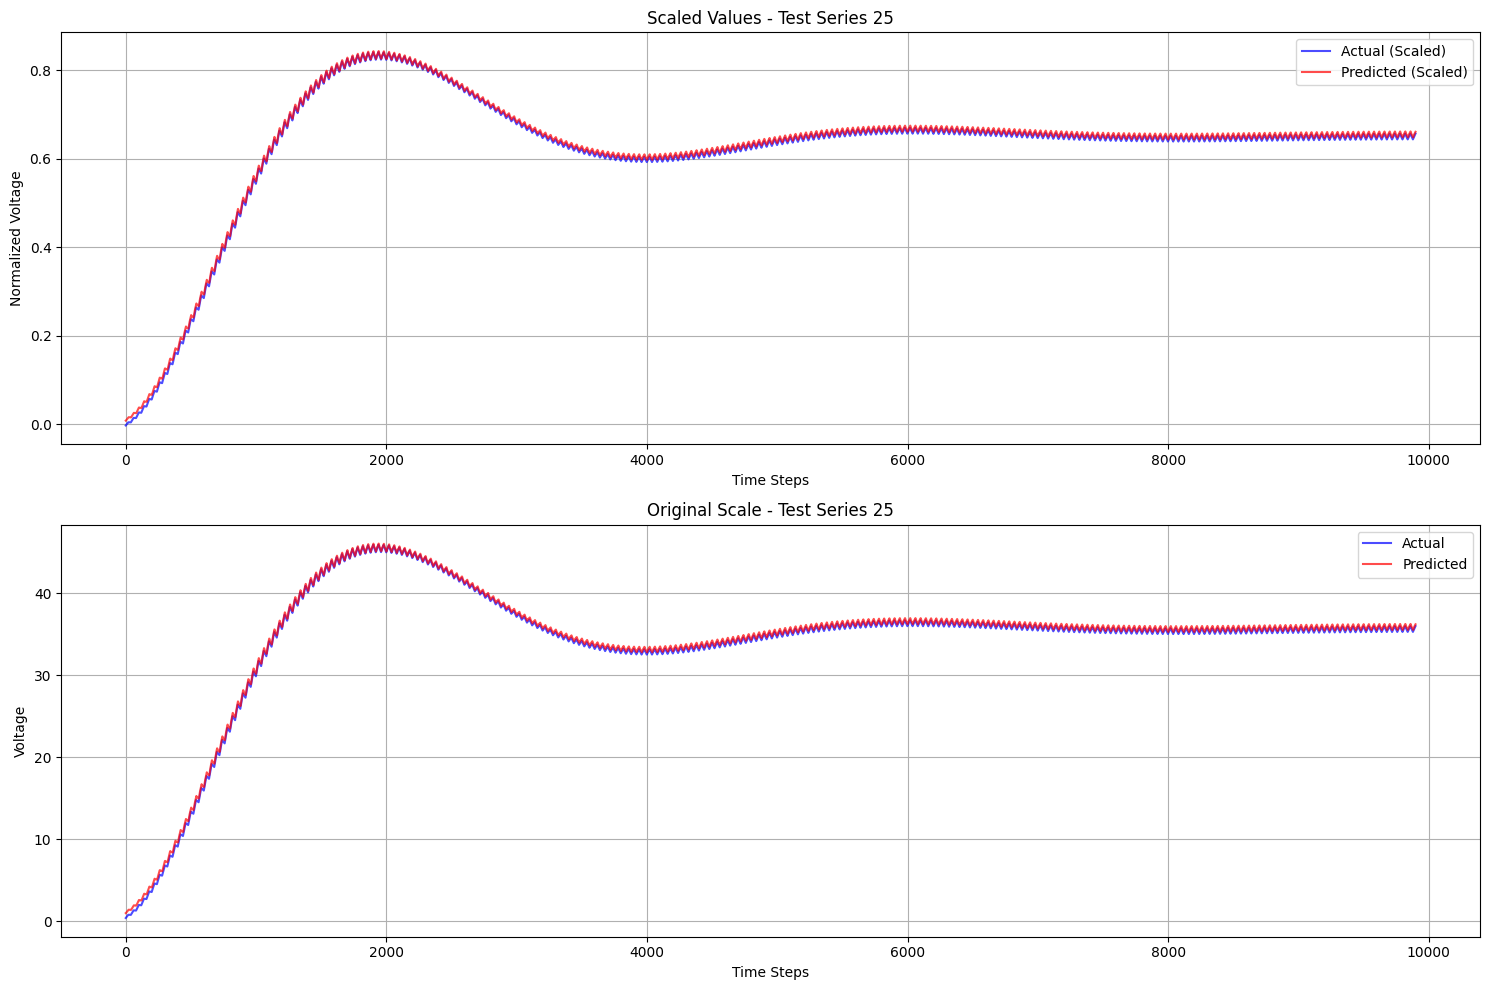

In [ ]:
# Get a specific test series
test_series_id = test_series[0]
series_mask = (series_ids_test == test_series_id)

# Get the scaled predictions and actual values
scaled_actual = y_test_scaled[series_mask]
scaled_pred = y_pred_scaled[series_mask]

# Inverse transform to get original scale
original_actual = scaler_y.inverse_transform(scaled_actual.reshape(-1, 1)).flatten()
original_pred = scaler_y.inverse_transform(scaled_pred.reshape(-1, 1)).flatten()

# Create subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10))

# Plot scaled values
ax1.plot(scaled_actual, label='Actual (Scaled)', color='blue', alpha=0.7)
ax1.plot(scaled_pred, label='Predicted (Scaled)', color='red', alpha=0.7)
ax1.set_title(f'Scaled Values - Test Series {test_series_id}')
ax1.set_xlabel('Time Steps')
ax1.set_ylabel('Normalized Voltage')
ax1.grid(True)
ax1.legend()

# Plot original values
ax2.plot(original_actual, label='Actual', color='blue', alpha=0.7)
ax2.plot(original_pred, label='Predicted', color='red', alpha=0.7)
ax2.set_title(f'Original Scale - Test Series {test_series_id}')
ax2.set_xlabel('Time Steps')
ax2.set_ylabel('Voltage')
ax2.grid(True)
ax2.legend()

# Adjust layout to prevent overlap
plt.tight_layout()

# Print some statistics
print("Scaled Values Range:")
print(f"Actual: [{scaled_actual.min():.3f}, {scaled_actual.max():.3f}]")
print(f"Predicted: [{scaled_pred.min():.3f}, {scaled_pred.max():.3f}]")
print("\nOriginal Values Range:")
print(f"Actual: [{original_actual.min():.3f}, {original_actual.max():.3f}]")
print(f"Predicted: [{original_pred.min():.3f}, {original_pred.max():.3f}]")

plt.show()

In [ ]:
# Create a DataFrame with original actual and predicted values
comparison_df = pd.DataFrame({
    'Original_Actual': original_actual,
    'Original_Predicted': original_pred
})

# Calculate error metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Calculate various metrics
mae = mean_absolute_error(comparison_df['Original_Actual'], comparison_df['Original_Predicted'])
mse = mean_squared_error(comparison_df['Original_Actual'], comparison_df['Original_Predicted'])
rmse = np.sqrt(mse)
r2 = r2_score(comparison_df['Original_Actual'], comparison_df['Original_Predicted'])

# Add absolute error column to dataframe
comparison_df['Absolute_Error'] = abs(comparison_df['Original_Actual'] - comparison_df['Original_Predicted'])

# Print metrics
print("\nError Metrics:")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R² Score: {r2:.4f}")

# Display first few rows of the comparison dataframe with errors
print("\nComparison DataFrame with Errors:")
print(comparison_df.head())

# Basic statistics of the absolute errors
print("\nAbsolute Error Statistics:")
print(comparison_df['Absolute_Error'].describe())


Error Metrics:
Mean Absolute Error (MAE): 0.2611
Mean Squared Error (MSE): 0.0762
Root Mean Squared Error (RMSE): 0.2761
R² Score: 0.9988

Comparison DataFrame with Errors:
   Original_Actual  Original_Predicted  Absolute_Error
0         0.389772            0.983981        0.594209
1         0.409004            0.992984        0.583979
2         0.428405            1.008767        0.580362
3         0.447974            1.028887        0.580913
4         0.467711            1.051213        0.583502

Absolute Error Statistics:
count    9900.000000
mean        0.261054
std         0.089826
min         0.006528
25%         0.210902
50%         0.254789
75%         0.299713
max         0.616888
Name: Absolute_Error, dtype: float64


In [ ]:
comparison_df[1000:1200]

,Original_Actual,Original_Predicted,Absolute_Error
1000,29.955024,30.182661,0.227637
1001,30.050719,30.205225,0.154506
1002,30.146209,30.285204,0.138994
1003,30.241494,30.401421,0.159926
1004,30.336573,30.532860,0.196287
...,...,...,...
1195,35.796399,36.114849,0.318450
1196,35.760556,36.078568,0.318011
1197,35.724750,36.037109,0.312359
1198,35.688981,35.991924,0.302943


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Embedding, Concatenate, Dropout, Reshape
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import tensorflow as tf

def build_pooled_brann_model(n_steps, n_features, n_series):
    """
    Build a pooled Bayesian Ridge ANN model with series identifiers
    """
    # Input layers
    time_series_input = Input(shape=(n_steps, n_features), name='time_series_input')
    series_id_input = Input(shape=(1,), name='series_id_input')

    # Embed the series identifier
    embedding_dim = min(5, (n_series + 1) // 2)  # Rule of thumb for embedding dimension
    series_embedding = Embedding(input_dim=n_series, output_dim=embedding_dim)(series_id_input)
    series_embedding = Dense(embedding_dim)(series_embedding)
    series_embedding = Dropout(0.2)(series_embedding)

    # Instead of LSTM, use Dense layers for BR-ANN
    # First flatten the time series input
    flattened_input = Reshape((n_steps * n_features,))(time_series_input)

    # Process flattened time series with dense layers
    dense1 = Dense(128, activation='relu')(flattened_input)
    dense1 = Dropout(0.2)(dense1)
    dense2 = Dense(64, activation='relu')(dense1)
    dense2 = Dropout(0.2)(dense2)

    # Flatten embedding before concatenation
    series_embedding_flat = Dense(embedding_dim, activation='relu')(series_embedding[:, 0, :])

    # Combine features
    concatenated = Concatenate()([dense2, series_embedding_flat])

    # Bayesian layers - use Dense with custom regularization for approximate Bayesian behavior
    bayesian_dense = Dense(32, activation='relu',
                          kernel_regularizer='l2',
                          bias_regularizer='l2')(concatenated)
    bayesian_dense = Dropout(0.3)(bayesian_dense)  # Dropout for uncertainty approximation

    # Output layer
    output = Dense(1)(bayesian_dense)

    # Define model
    model = Model(inputs=[time_series_input, series_id_input], outputs=output)

    # Use Adam optimizer with a smaller learning rate for better convergence
    from tensorflow.keras.optimizers import Adam
    optimizer = Adam(learning_rate=0.001)

    # Compile model
    model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])

    return model

# Main execution code
# Assuming these variables are already defined from your LSTM model:
# X_train_scaled, X_test_scaled, y_train_scaled, y_test_scaled,
# series_ids_train, series_ids_test, series_ids, test_series

# Get dimensions for model
n_steps = X_train_scaled.shape[1]  # Number of time steps from your data
n_features = X_train_scaled.shape[2]  # Number of features from your data
n_series = len(np.unique(series_ids))  # Number of unique series IDs

# Build the BR-ANN model
brann_model = build_pooled_brann_model(n_steps, n_features, n_series)

# Display model summary
brann_model.summary()

# Reshape series IDs for model input
train_series_ids = series_ids_train.reshape(-1, 1)
test_series_ids = series_ids_test.reshape(-1, 1)

# Define callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

model_checkpoint = ModelCheckpoint(
    'best_brann_model.h5',
    monitor='val_loss',
    save_best_only=True
)

# Train the BR-ANN model
brann_history = brann_model.fit(
    [X_train_scaled, train_series_ids],  # Same input data used in LSTM
    y_train_scaled,                       # Same target data used in LSTM
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping, model_checkpoint],
    verbose=1
)

# Get predictions from BR-ANN model

print(f"Overall BR-ANN MSE: {brann_overall_mse:.4f}, MAE: {brann_overall_mae:.4f}")

# Plot error comparison by series
# plt.figure(figsize=(14, 6))

# # Plot MSE comparison
# plt.subplot(1, 2, 1)
# series_indices = range(len(unique_test_series))
# bar_width = 0.35
# plt.bar(series_indices, lstm_error_df['MSE'], bar_width, label='LSTM', alpha=0.7)
# plt.bar([x + bar_width for x in series_indices], brann_error_df['MSE'], bar_width, label='BR-ANN', alpha=0.7)
# plt.xticks([x + bar_width/2 for x in series_indices], unique_test_series)
# plt.xlabel('Series ID')
# plt.ylabel('Mean Squared Error')
# plt.title('MSE by Series: LSTM vs BR-ANN')
# plt.legend()

# # Plot MAE comparison
# plt.subplot(1, 2, 2)
# plt.bar(series_indices, lstm_error_df['MAE'], bar_width, label='LSTM', alpha=0.7)
# plt.bar([x + bar_width for x in series_indices], brann_error_df['MAE'], bar_width, label='BR-ANN', alpha=0.7)
# plt.xticks([x + bar_width/2 for x in series_indices], unique_test_series)
# plt.xlabel('Series ID')
# plt.ylabel('Mean Absolute Error')
# plt.title('MAE by Series: LSTM vs BR-ANN')
# plt.legend()

# plt.tight_layout()
# plt.show()

# # Create a plot comparing the training history of both models
# # Assuming lstm_history is available from your LSTM model training
# # If not, comment out this section
# """
# plt.figure(figsize=(14, 6))

# # Plot training loss comparison
# plt.subplot(1, 2, 1)
# plt.plot(lstm_history.history['loss'], label='LSTM Training Loss')
# plt.plot(lstm_history.history['val_loss'], label='LSTM Validation Loss')
# plt.plot(brann_history.history['loss'], label='BR-ANN Training Loss')
# plt.plot(brann_history.history['val_loss'], label='BR-ANN Validation Loss')
# plt.xlabel('Epoch')
# plt.ylabel('Loss (MSE)')
# plt.title('Training Loss: LSTM vs BR-ANN')
# plt.legend()

# # Plot training MAE comparison
# plt.subplot(1, 2, 2)
# plt.plot(lstm_history.history['mae'], label='LSTM Training MAE')
# plt.plot(lstm_history.history['val_mae'], label='LSTM Validation MAE')
# plt.plot(brann_history.history['mae'], label='BR-ANN Training MAE')
# plt.plot(brann_history.history['val_mae'], label='BR-ANN Validation MAE')
# plt.xlabel('Epoch')
# plt.ylabel('MAE')
# plt.title('Training MAE: LSTM vs BR-ANN')
# plt.legend()

# plt.tight_layout()
# plt.show()
# """

# # Plot predictions vs actual for multiple test series (choose up to 4 series)
# num_series_to_plot = min(4, len(unique_test_series))
# selected_series = unique_test_series[:num_series_to_plot]

# fig, axes = plt.subplots(num_series_to_plot, 1, figsize=(14, 4*num_series_to_plot))

# for i, series_id in enumerate(selected_series):
#     series_mask = (series_ids_test == series_id)

#     if num_series_to_plot > 1:
#         ax = axes[i]
#     else:
#         ax = axes  # For single subplot case

#     ax.plot(y_test_scaled[series_mask], 'b-', label='Actual', alpha=0.7)
#     ax.plot(lstm_pred_scaled[series_mask], 'g-', label='LSTM', alpha=0.6)
#     ax.plot(brann_pred_scaled[series_mask], 'r-', label='BR-ANN', alpha=0.6)
#     ax.set_title(f'Series {series_id} Predictions')
#     ax.set_xlabel('Time Steps')
#     ax.set_ylabel('Scaled Voltage')
#     ax.grid(True)
#     ax.legend()

# plt.tight_layout()
# plt.show()

# # Calculate error distribution
# lstm_errors_all = (y_test_scaled - lstm_pred_scaled).flatten()
# brann_errors_all = (y_test_scaled - brann_pred_scaled).flatten()

# # Plot error distribution
# plt.figure(figsize=(14, 6))

# plt.subplot(1, 2, 1)
# plt.hist(lstm_errors_all, bins=50, alpha=0.7, label='LSTM Errors')
# plt.hist(brann_errors_all, bins=50, alpha=0.7, label='BR-ANN Errors')
# plt.xlabel('Prediction Error')
# plt.ylabel('Frequency')
# plt.title('Error Distribution: LSTM vs BR-ANN')
# plt.legend()

# plt.subplot(1, 2, 2)
# plt.boxplot([lstm_errors_all, brann_errors_all], labels=['LSTM', 'BR-ANN'])
# plt.ylabel('Prediction Error')
# plt.title('Error Distribution Box Plot')

# plt.tight_layout()
# plt.show()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ time_series_input   │ (None, 100, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ series_id_input     │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 100)       │          0 │ time_series_inpu… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 1, 5)      │        160 │ series_id_input[… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │     12,928 │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 1, 5)      │         30 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 1, 5)      │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │      8,256 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 5)         │          0 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64)        │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 5)         │         30 │ get_item[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 69)        │          0 │ dropout_2[0][0],  │
│ (Concatenate)       │                   │            │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 32)        │      2,240 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 32)        │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 1)         │         33 │ dropout_3[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,677 (92.49 KB)

 Trainable params: 23,677 (92.49 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
6184/6188 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0753 - mae: 0.1072

6188/6188 ━━━━━━━━━━━━━━━━━━━━ 31s 4ms/step - loss: 0.0753 - mae: 0.1071 - val_loss: 0.0038 - val_mae: 0.0379
Epoch 2/50
6172/6188 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0037 - mae: 0.0376

6188/6188 ━━━━━━━━━━━━━━━━━━━━ 40s 4ms/step - loss: 0.0037 - mae: 0.0376 - val_loss: 0.0027 - val_mae: 0.0407
Epoch 3/50
6188/6188 ━━━━━━━━━━━━━━━━━━━━ 39s 4ms/step - loss: 0.0031 - mae: 0.0330 - val_loss: 0.0041 - val_mae: 0.0542
Epoch 4/50
6188/6188 ━━━━━━━━━━━━━━━━━━━━ 25s 4ms/step - loss: 0.0029 - mae: 0.0313 - val_loss: 0.0091 - val_mae: 0.0847
Epoch 5/50
6188/6188 ━━━━━━━━━━━━━━━━━━━━ 44s 4ms/step - loss: 0.0028 - mae: 0.0305 - val_loss: 0.0113 - val_mae: 0.0936
Epoch 6/50
6188/6188 ━━━━━━━━━━━━━━━━━━━━ 27s 4ms/step - loss: 0.0027 - mae: 0.0297 - val_loss: 0.0115 - val_mae: 0.0965
Epoch 7/50
6188/6188 ━━━━━━━━━━━━━━━━━━━━ 27s 4ms/step - loss: 0.0026 - mae: 0.0294 - val_loss: 0.0069 - val_mae: 0.0754
Epoch 8/50
6188/6188 ━━━━━━━━━━━━━━━━━━━━ 24s 4ms/step - loss: 0.0025 - mae: 0.0290 - val_loss: 0.0079 - val_mae: 0.0819
Epoch 9/50
6188/6188 ━━━━━━━━━━━━━━━━━━━━ 26s 4ms/step - loss: 0.0026 - mae: 0.0296 - val_loss: 0.0090 - val_mae: 0.0861
Epoch 10/50
6188/6188 ━━━━━━━━━━━━━━━━━━━━ 

NameError: name 'brann_overall_mse' is not defined

In [ ]:
brann_pred_scaled = brann_model.predict([X_test_scaled, test_series_ids])



2166/2166 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step



Evaluation Metrics by Series:
   Series_ID       MAE        MSE      RMSE  MAE_Scaled  MSE_Scaled
0         25  1.310112   2.046095  1.430418    0.024277    0.000703
1         26  1.220317   1.879972  1.371121    0.022613    0.000646
2         27  2.188284   5.232898  2.287553    0.040550    0.001797
3         28  3.656534  16.199052  4.024805    0.067758    0.005563
4         29  2.523350   7.767679  2.787056    0.046759    0.002667
5         30  2.500732   8.597034  2.932070    0.046340    0.002952
6         31  2.346101   6.275067  2.505008    0.043475    0.002155


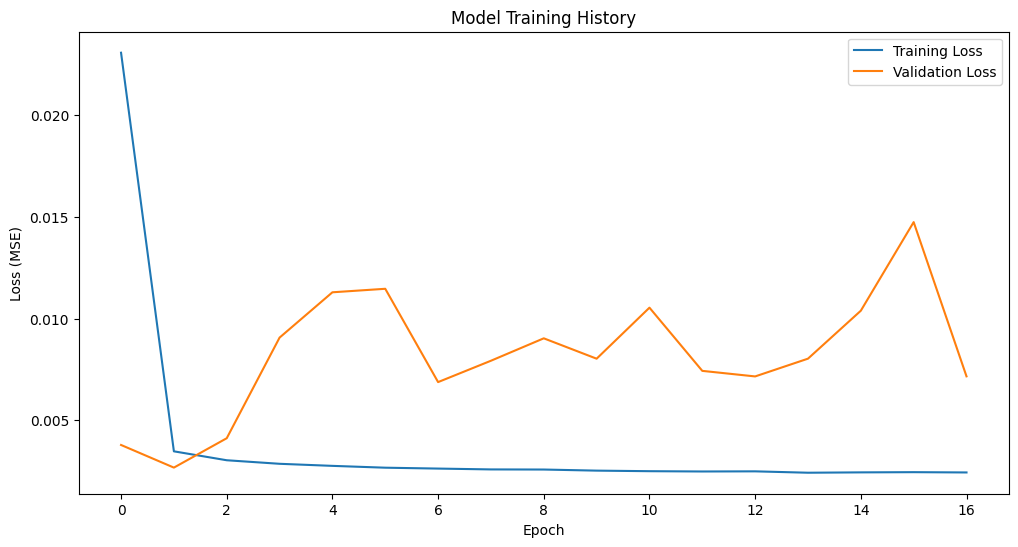

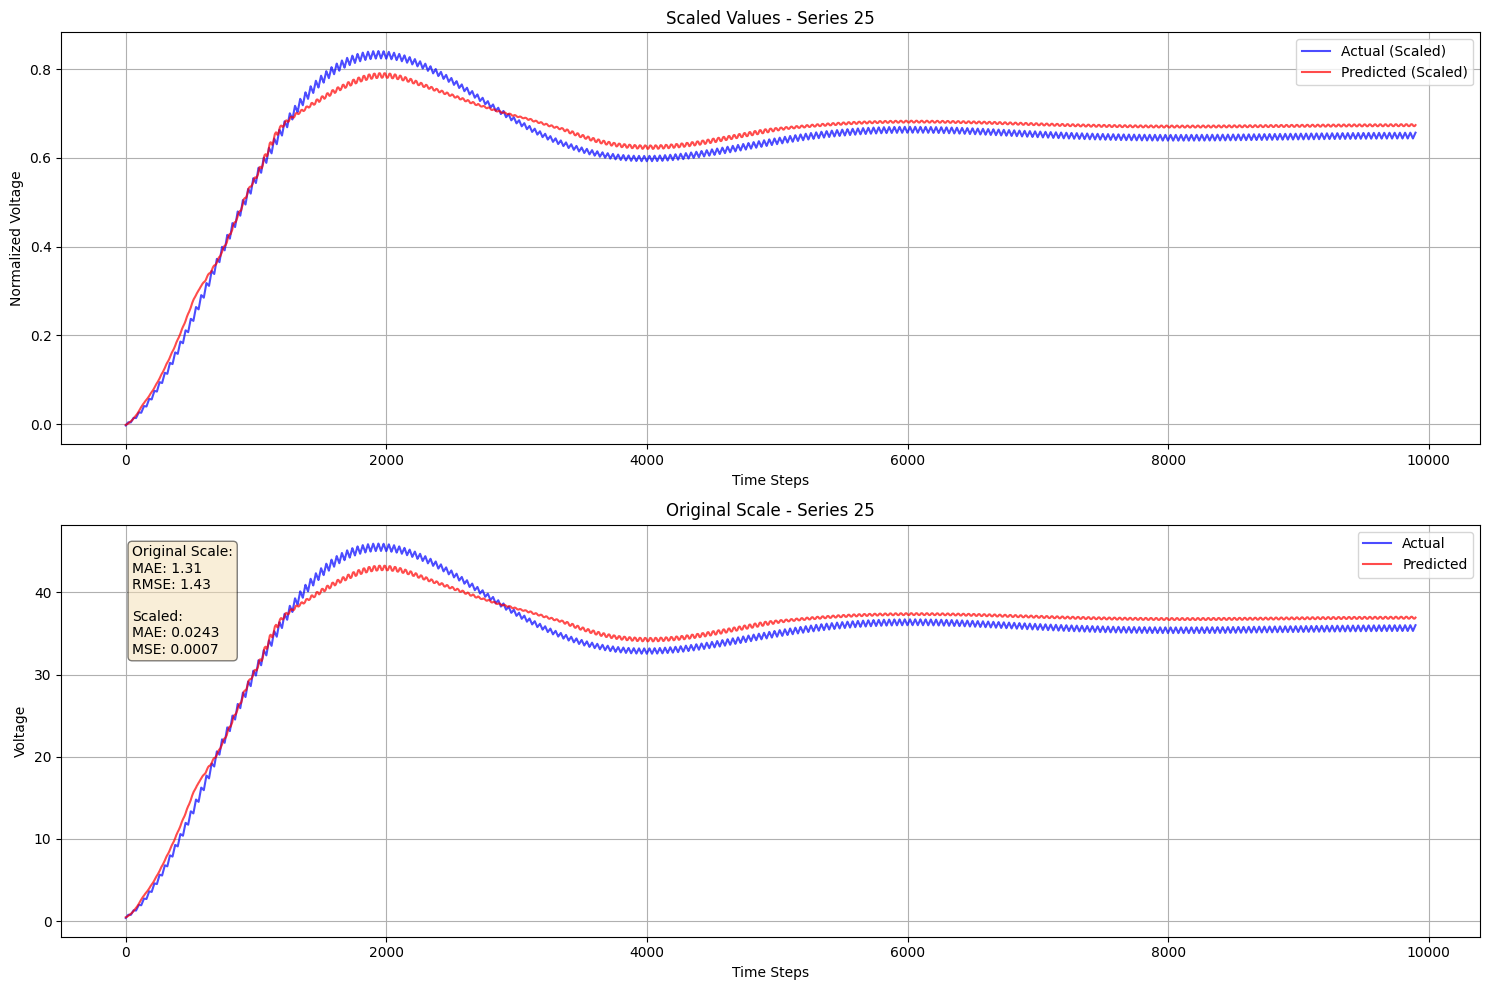

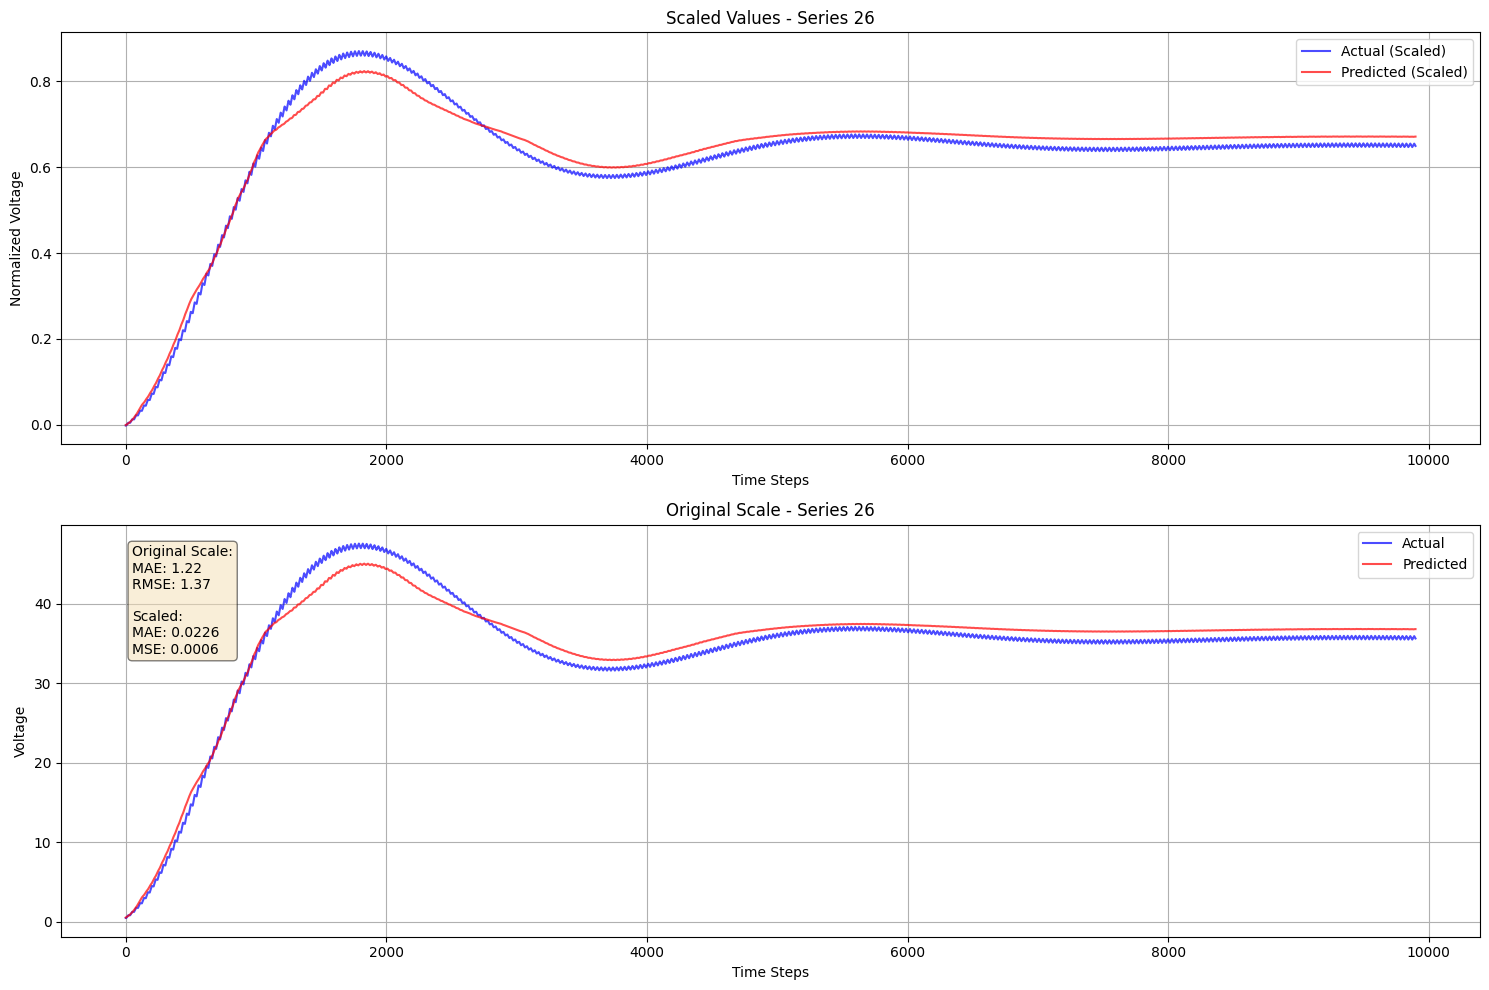

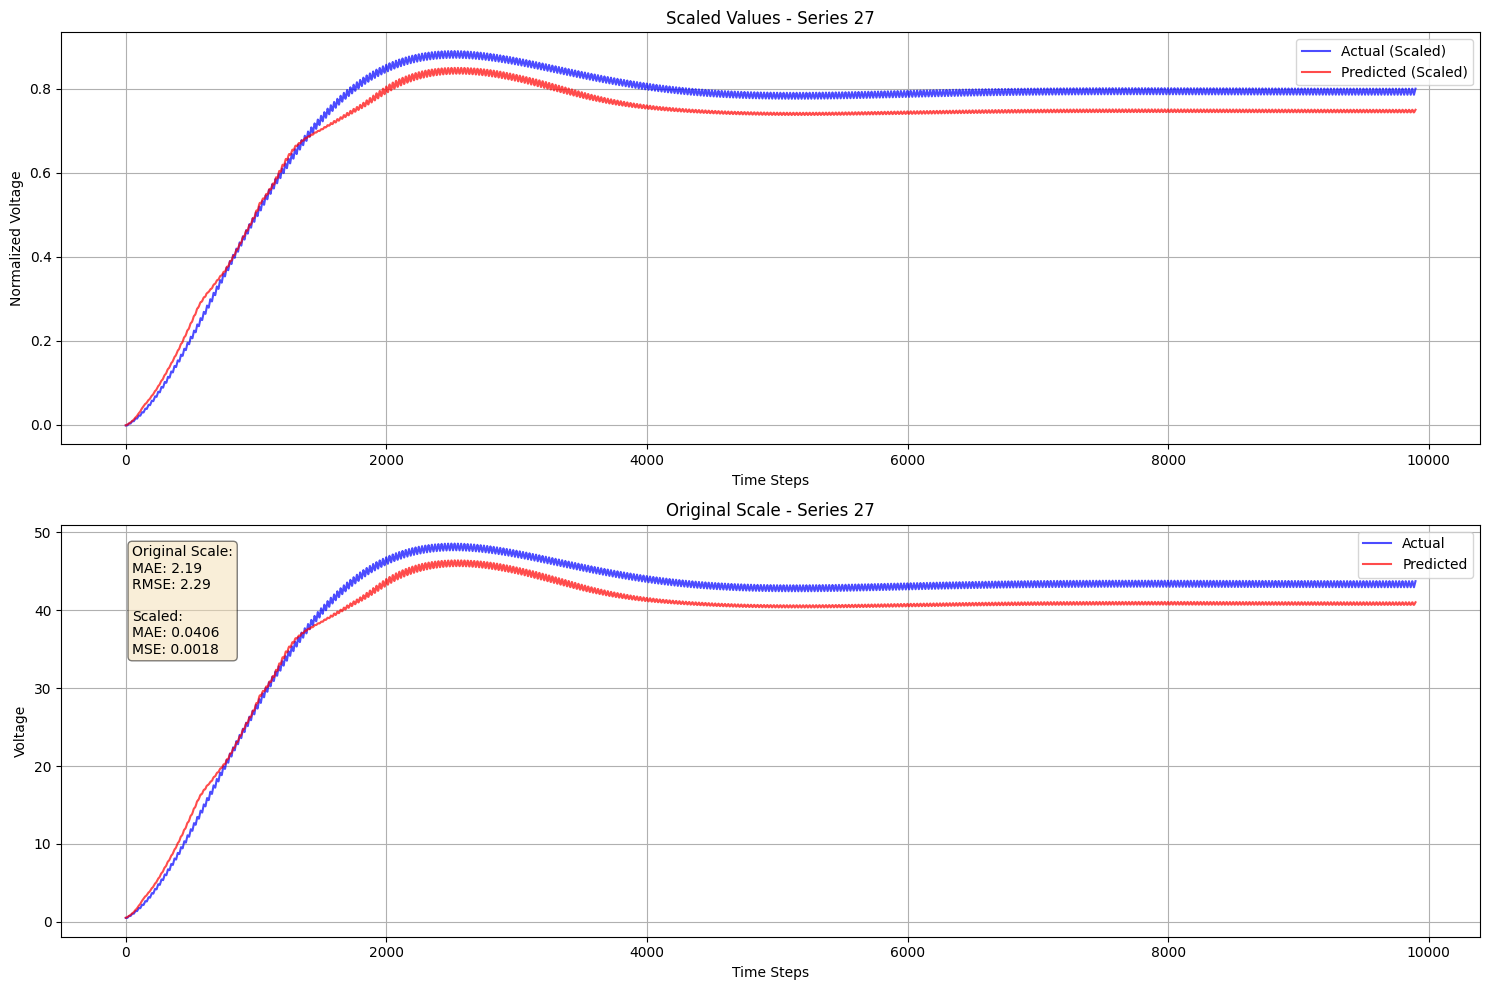

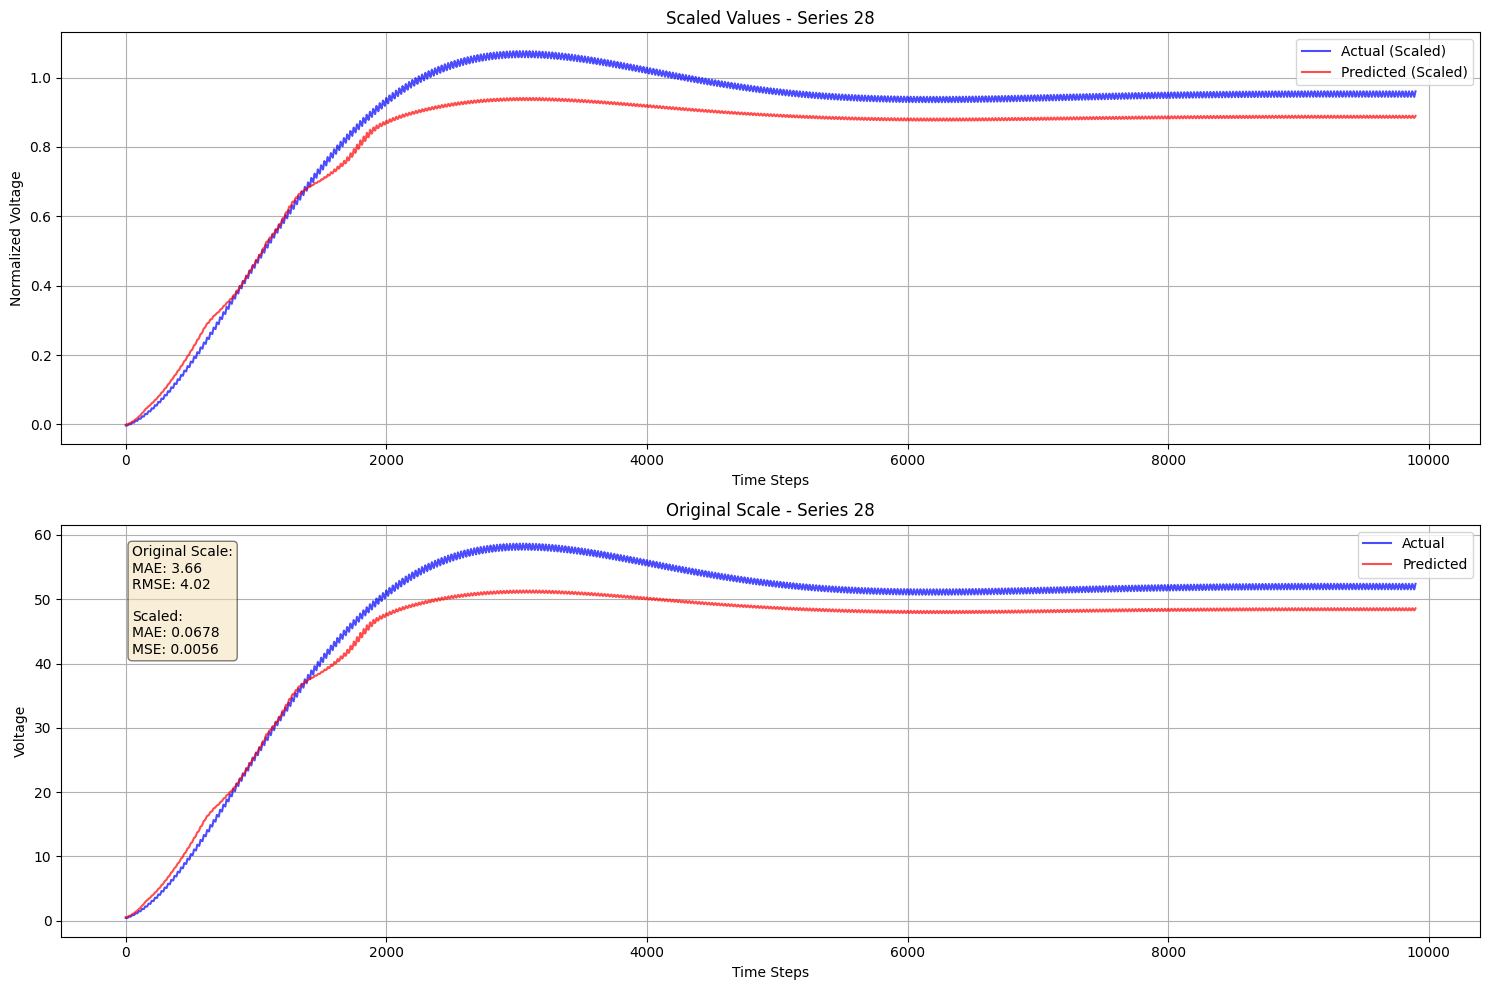

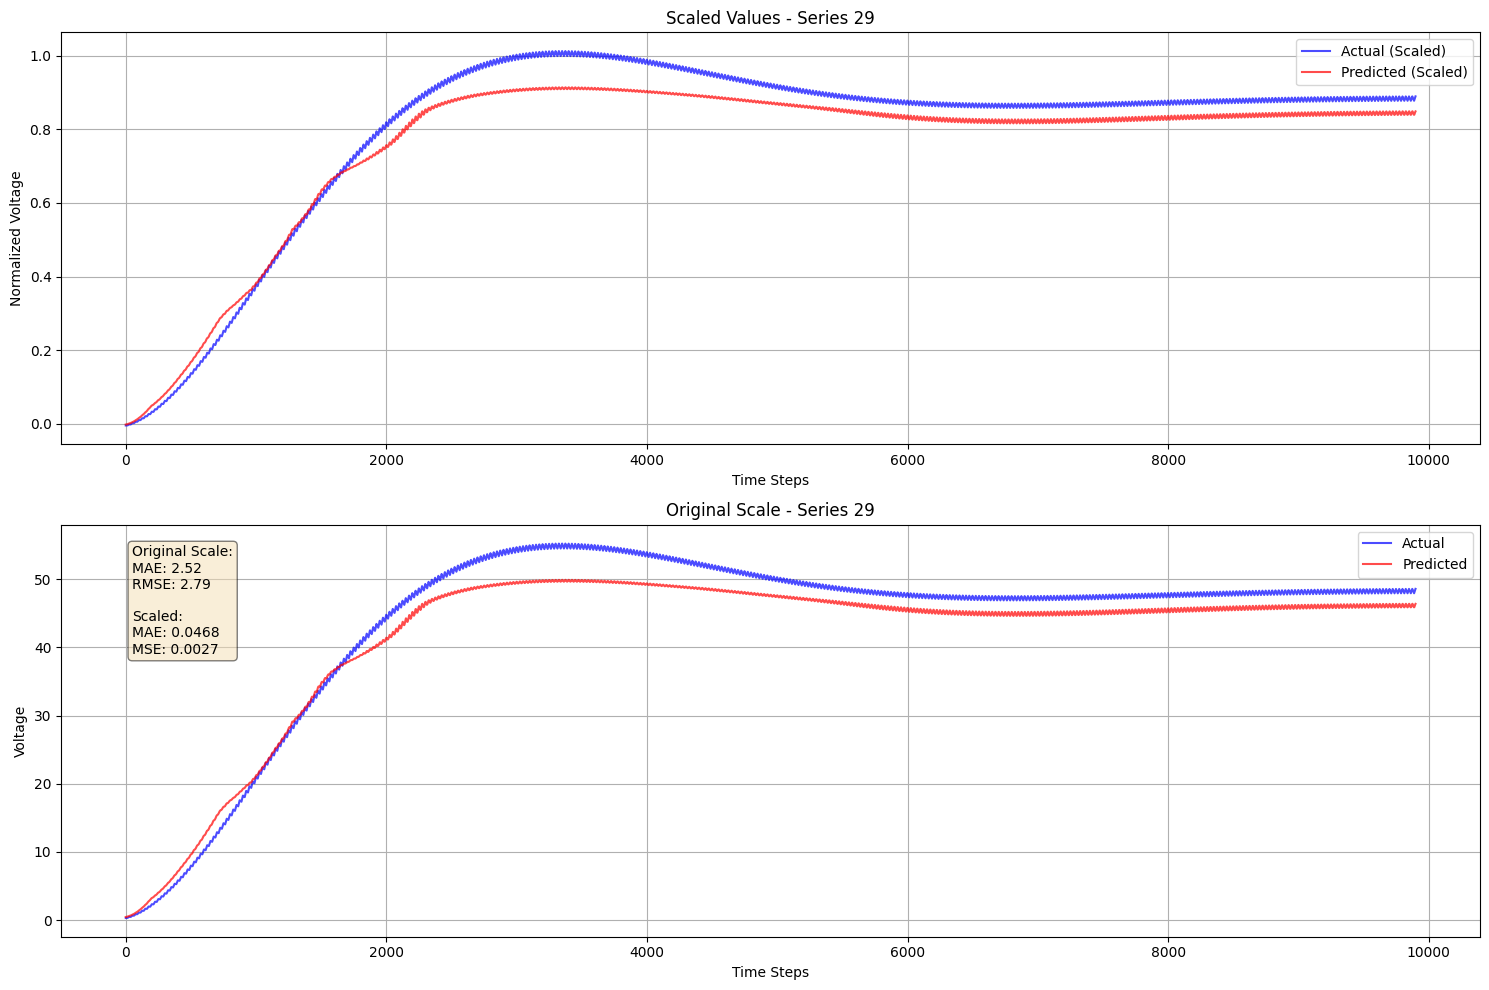

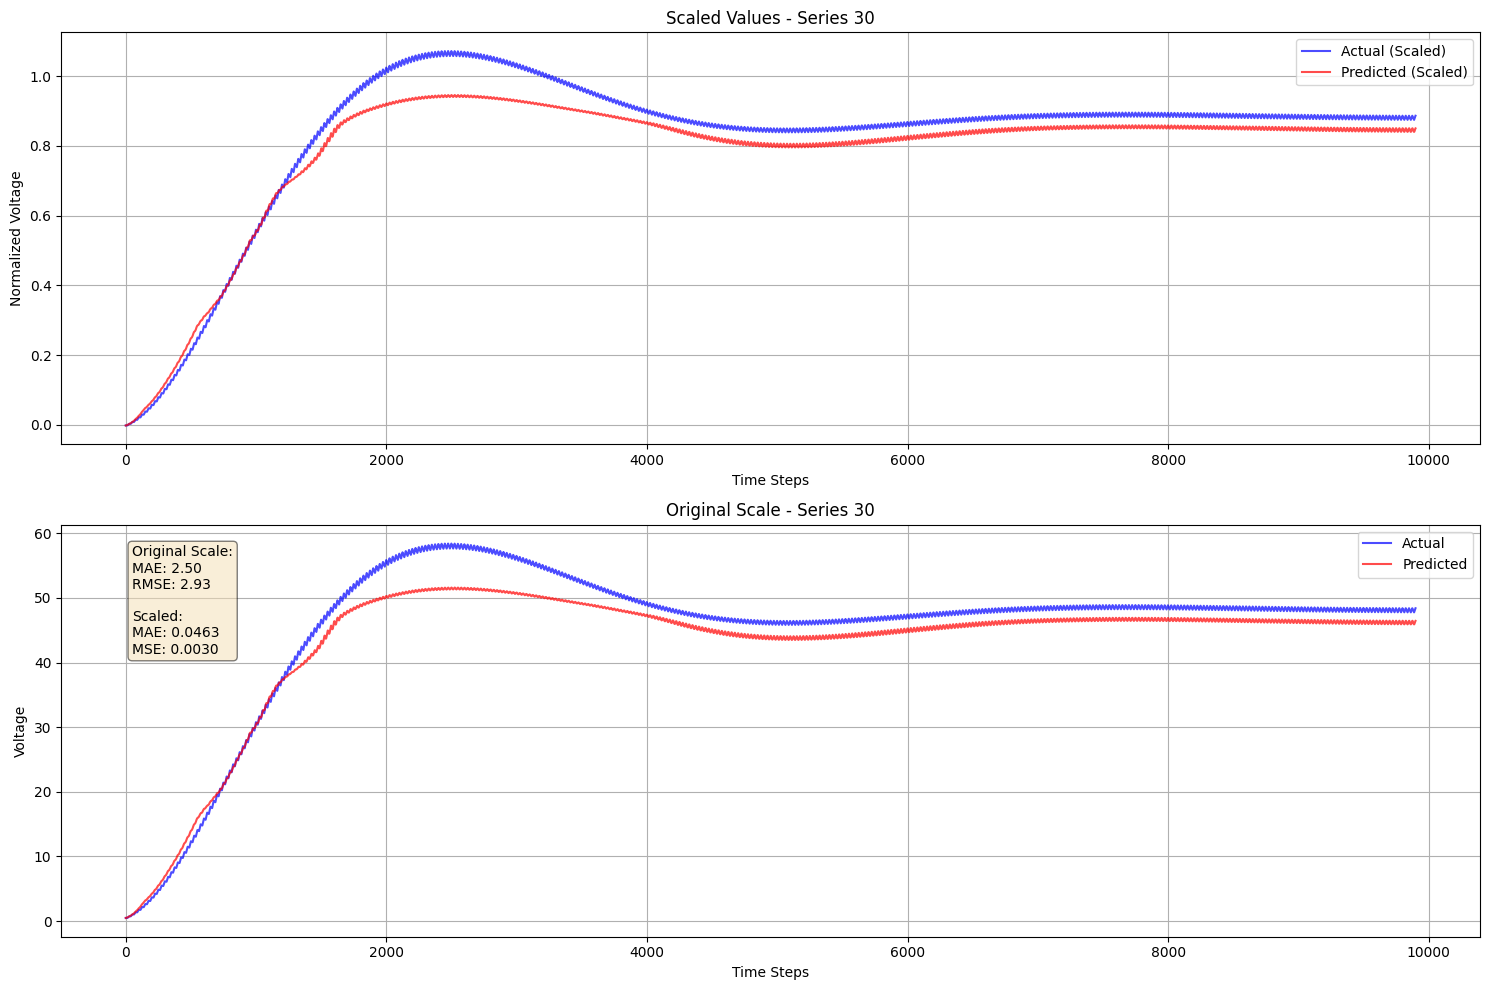

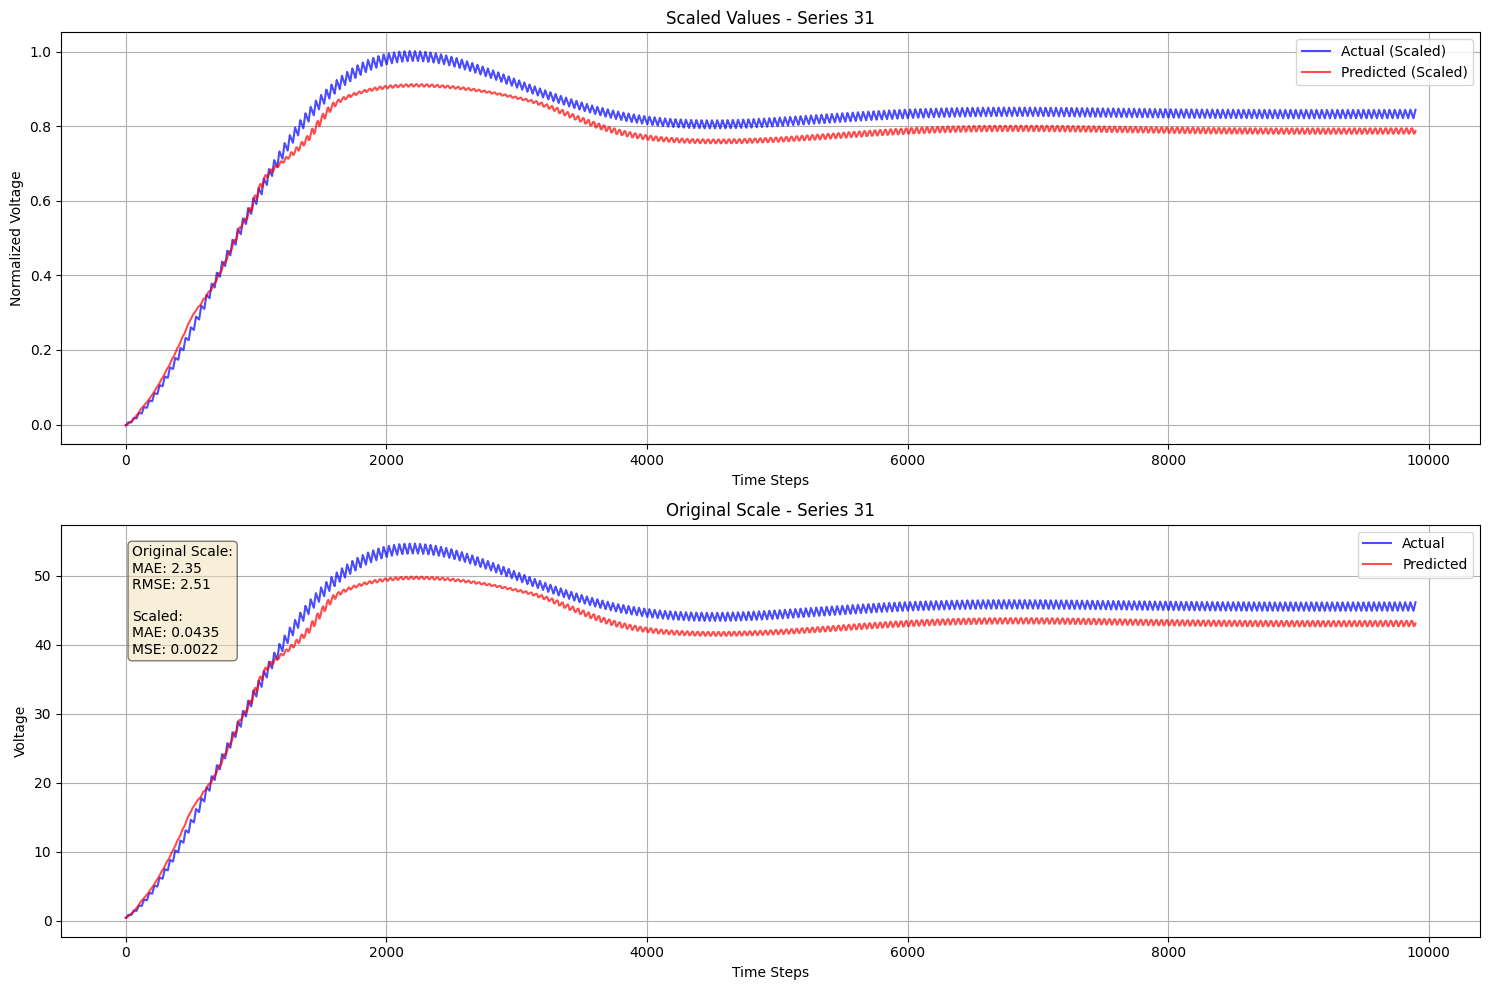


Scaled Values Range Across All Series:
Actual: [-0.005, 1.077]
Predicted: [-0.002, 0.946]

Original Values Range Across All Series:
Actual: [0.298, 58.666]
Predicted: [0.441, 51.600]

Overall Evaluation Metrics:
Original Scale:
MAE: 2.2493
MSE: 6.8568
RMSE: 2.6186

Scaled:
MAE: 0.0417
MSE: 0.0024


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 1. Inverse transform the scaled predictions and actual values
brann_pred = scaler_y.inverse_transform(brann_pred_scaled)
y_test = scaler_y.inverse_transform(y_test_scaled.reshape(-1, 1))

# 2. Create a DataFrame with the results and series IDs
results_df = pd.DataFrame({
    'Series_ID': series_ids_test.flatten(),
    'Actual': y_test.flatten(),
    'Predicted': brann_pred.flatten(),
    'Actual_Scaled': y_test_scaled.flatten(),
    'Predicted_Scaled': brann_pred_scaled.flatten()
})

# 3. Calculate metrics for each series (both scaled and original)
series_metrics = []
unique_series = results_df['Series_ID'].unique()

for series_id in unique_series:
    series_data = results_df[results_df['Series_ID'] == series_id]

    # Original scale metrics
    actual = series_data['Actual']
    predicted = series_data['Predicted']
    mae = mean_absolute_error(actual, predicted)
    mse = mean_squared_error(actual, predicted)
    rmse = np.sqrt(mse)

    # Scaled metrics
    actual_scaled = series_data['Actual_Scaled']
    predicted_scaled = series_data['Predicted_Scaled']
    mae_scaled = mean_absolute_error(actual_scaled, predicted_scaled)
    mse_scaled = mean_squared_error(actual_scaled, predicted_scaled)

    series_metrics.append({
        'Series_ID': series_id,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'MAE_Scaled': mae_scaled,
        'MSE_Scaled': mse_scaled
    })

# Convert metrics to DataFrame
metrics_df = pd.DataFrame(series_metrics)
print("\nEvaluation Metrics by Series:")
print(metrics_df)

# 4. Plot training history
plt.figure(figsize=(12, 6))
plt.plot(brann_history.history['loss'], label='Training Loss')
plt.plot(brann_history.history['val_loss'], label='Validation Loss')
plt.title('Model Training History')
plt.ylabel('Loss (MSE)')
plt.xlabel('Epoch')
plt.legend()
plt.show()

# 5. Plot actual vs predicted for each series (both scaled and original)
for series_id in unique_series:
    series_data = results_df[results_df['Series_ID'] == series_id]

    # Create subplots
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10))

    # Plot scaled values
    ax1.plot(series_data['Actual_Scaled'].values, label='Actual (Scaled)', color='blue', alpha=0.7)
    ax1.plot(series_data['Predicted_Scaled'].values, label='Predicted (Scaled)', color='red', alpha=0.7)
    ax1.set_title(f'Scaled Values - Series {series_id}')
    ax1.set_xlabel('Time Steps')
    ax1.set_ylabel('Normalized Voltage')
    ax1.grid(True)
    ax1.legend()

    # Plot original values
    ax2.plot(series_data['Actual'].values, label='Actual', color='blue', alpha=0.7)
    ax2.plot(series_data['Predicted'].values, label='Predicted', color='red', alpha=0.7)
    ax2.set_title(f'Original Scale - Series {series_id}')
    ax2.set_xlabel('Time Steps')
    ax2.set_ylabel('Voltage')
    ax2.grid(True)
    ax2.legend()

    # Get metrics for this series
    metrics = metrics_df[metrics_df['Series_ID'] == series_id].iloc[0]

    # Add metrics text box
    textstr = '\n'.join((
        f'Original Scale:',
        f'MAE: {metrics["MAE"]:.2f}',
        f'RMSE: {metrics["RMSE"]:.2f}',
        f'\nScaled:',
        f'MAE: {metrics["MAE_Scaled"]:.4f}',
        f'MSE: {metrics["MSE_Scaled"]:.4f}'
    ))
    props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
    ax2.text(0.05, 0.95, textstr, transform=ax2.transAxes,
            fontsize=10, verticalalignment='top', bbox=props)

    plt.tight_layout()
    plt.show()

# 6. Print value ranges for all series
print("\nScaled Values Range Across All Series:")
print(f"Actual: [{results_df['Actual_Scaled'].min():.3f}, {results_df['Actual_Scaled'].max():.3f}]")
print(f"Predicted: [{results_df['Predicted_Scaled'].min():.3f}, {results_df['Predicted_Scaled'].max():.3f}]")
print("\nOriginal Values Range Across All Series:")
print(f"Actual: [{results_df['Actual'].min():.3f}, {results_df['Actual'].max():.3f}]")
print(f"Predicted: [{results_df['Predicted'].min():.3f}, {results_df['Predicted'].max():.3f}]")

# 7. Calculate and print overall metrics
overall_mae = mean_absolute_error(results_df['Actual'], results_df['Predicted'])
overall_mse = mean_squared_error(results_df['Actual'], results_df['Predicted'])
overall_rmse = np.sqrt(overall_mse)
overall_mae_scaled = mean_absolute_error(results_df['Actual_Scaled'], results_df['Predicted_Scaled'])
overall_mse_scaled = mean_squared_error(results_df['Actual_Scaled'], results_df['Predicted_Scaled'])

print("\nOverall Evaluation Metrics:")
print("Original Scale:")
print(f"MAE: {overall_mae:.4f}")
print(f"MSE: {overall_mse:.4f}")
print(f"RMSE: {overall_rmse:.4f}")
print("\nScaled:")
print(f"MAE: {overall_mae_scaled:.4f}")
print(f"MSE: {overall_mse_scaled:.4f}")

<ipython-input-10-2fcf6f1cf2ad>:71: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  error_metrics_df_formatted = error_metrics_df.applymap(format_float)


Comprehensive Error Metrics by Series:


,Series_ID,MAE,MSE,RMSE,MAPE,Correlation,Actual_Min,Actual_Max,Predicted_Min,Predicted_Max,MAE_Scaled,MSE_Scaled,Count
0,25,1.3101,2.0461,1.4304,4.2946,0.9884,0.3898,45.9246,0.4751,43.2299,0.0243,0.0007,9900
1,26,1.2203,1.8800,1.3711,3.8870,0.9887,0.4936,47.5458,0.5504,45.0297,0.0226,0.0006,9900
2,27,2.1883,5.2329,2.2876,6.0289,0.9981,0.4875,48.5783,0.5238,46.4183,0.0406,0.0018,9900
3,28,3.6565,16.1991,4.0248,8.3992,0.9960,0.4032,58.6663,0.5268,51.3761,0.0678,0.0056,9900
4,29,2.5233,7.7677,2.7871,7.2202,0.9975,0.2983,55.2454,0.4407,49.9202,0.0468,0.0027,9900
5,30,2.5007,8.5970,2.9321,5.8237,0.9946,0.4781,58.4098,0.4728,51.5997,0.0463,0.0030,9900
6,31,2.3461,6.2751,2.5050,5.7124,0.9977,0.4276,54.6583,0.5013,49.8750,0.0435,0.0022,9900
7,ALL SERIES,2.2493,6.8568,2.6186,5.9094,0.9921,0.2983,58.6663,0.4407,51.5997,0.0417,0.0024,69300



Metrics saved to 'series_error_metrics.csv'


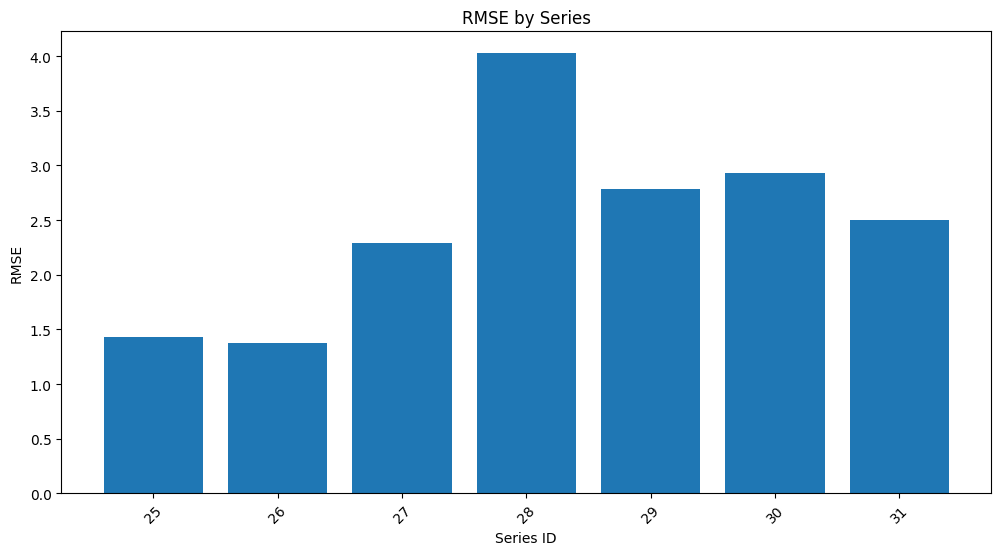

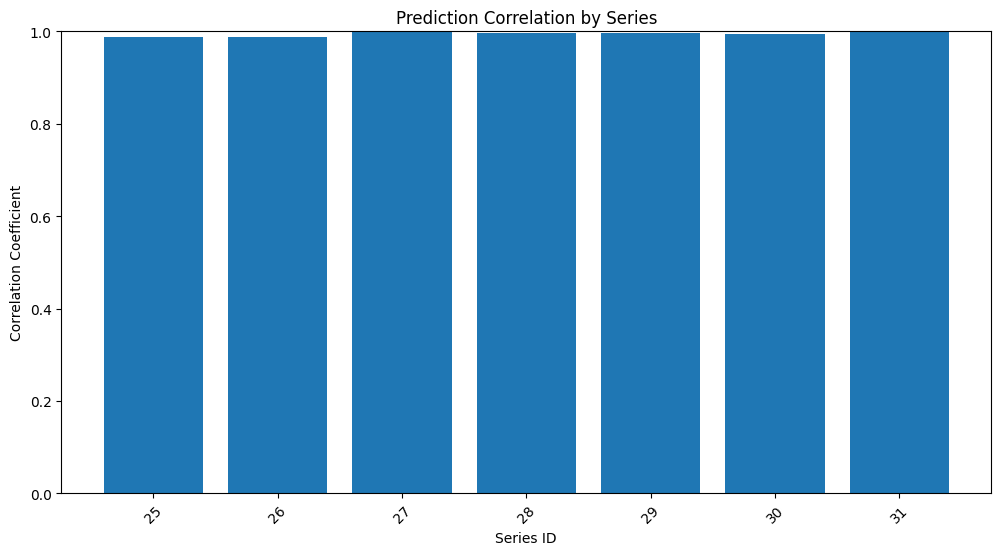

In [ ]:
# Create a DataFrame with all series and their error metrics
series_results = []

for series_id in unique_series:
    series_data = results_df[results_df['Series_ID'] == series_id]
    actual = series_data['Actual']
    predicted = series_data['Predicted']
    actual_scaled = series_data['Actual_Scaled']
    predicted_scaled = series_data['Predicted_Scaled']

    # Calculate metrics
    mae = mean_absolute_error(actual, predicted)
    mse = mean_squared_error(actual, predicted)
    rmse = np.sqrt(mse)
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100  # Mean Absolute Percentage Error

    mae_scaled = mean_absolute_error(actual_scaled, predicted_scaled)
    mse_scaled = mean_squared_error(actual_scaled, predicted_scaled)

    # Calculate correlation
    correlation = np.corrcoef(actual, predicted)[0, 1]

    # Get value ranges
    actual_min, actual_max = actual.min(), actual.max()
    pred_min, pred_max = predicted.min(), predicted.max()

    series_results.append({
        'Series_ID': series_id,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'MAPE': mape,
        'Correlation': correlation,
        'Actual_Min': actual_min,
        'Actual_Max': actual_max,
        'Predicted_Min': pred_min,
        'Predicted_Max': pred_max,
        'MAE_Scaled': mae_scaled,
        'MSE_Scaled': mse_scaled,
        'Count': len(series_data)  # Number of observations in this series
    })

# Create the DataFrame
error_metrics_df = pd.DataFrame(series_results)

# Add overall metrics as the last row
overall_metrics = {
    'Series_ID': 'ALL SERIES',
    'MAE': mean_absolute_error(results_df['Actual'], results_df['Predicted']),
    'MSE': mean_squared_error(results_df['Actual'], results_df['Predicted']),
    'RMSE': np.sqrt(mean_squared_error(results_df['Actual'], results_df['Predicted'])),
    'MAPE': np.mean(np.abs((results_df['Actual'] - results_df['Predicted']) / results_df['Actual'])) * 100,
    'Correlation': np.corrcoef(results_df['Actual'], results_df['Predicted'])[0, 1],
    'Actual_Min': results_df['Actual'].min(),
    'Actual_Max': results_df['Actual'].max(),
    'Predicted_Min': results_df['Predicted'].min(),
    'Predicted_Max': results_df['Predicted'].max(),
    'MAE_Scaled': mean_absolute_error(results_df['Actual_Scaled'], results_df['Predicted_Scaled']),
    'MSE_Scaled': mean_squared_error(results_df['Actual_Scaled'], results_df['Predicted_Scaled']),
    'Count': len(results_df)
}

error_metrics_df = pd.concat([error_metrics_df, pd.DataFrame([overall_metrics])], ignore_index=True)

# Format the DataFrame for better display
def format_float(x):
    if isinstance(x, (float, np.floating)):
        return f"{x:.4f}"
    return x

error_metrics_df_formatted = error_metrics_df.applymap(format_float)

# Display the DataFrame
print("Comprehensive Error Metrics by Series:")
display(error_metrics_df_formatted)

# Save to CSV
error_metrics_df.to_csv('series_error_metrics.csv', index=False)
print("\nMetrics saved to 'series_error_metrics.csv'")

# Additional visualizations
plt.figure(figsize=(12, 6))
plt.bar(error_metrics_df[:-1]['Series_ID'].astype(str), error_metrics_df[:-1]['RMSE'])
plt.title('RMSE by Series')
plt.xlabel('Series ID')
plt.ylabel('RMSE')
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(12, 6))
plt.bar(error_metrics_df[:-1]['Series_ID'].astype(str), error_metrics_df[:-1]['Correlation'])
plt.title('Prediction Correlation by Series')
plt.xlabel('Series ID')
plt.ylabel('Correlation Coefficient')
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.show()

<ipython-input-11-ebd6f76dae64>:51: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  series_comparison_df_formatted = series_comparison_df.applymap(format_float)



Detailed Comparison for Series 25:


,Time_Step,Actual,Predicted,Actual_Scaled,Predicted_Scaled,Absolute_Error,Absolute_Error_Scaled,Percentage_Error,Rolling_MAE,Rolling_MAE_Scaled
0,0,0.3898,0.4751,-0.0033,-0.0018,0.0854,0.0016,21.9032,NaN,NaN
1,1,0.4090,0.4805,-0.0030,-0.0017,0.0715,0.0013,17.4907,NaN,NaN
2,2,0.4284,0.4857,-0.0026,-0.0016,0.0573,0.0011,13.3826,0.0714,0.0013
3,3,0.4480,0.4919,-0.0023,-0.0015,0.0439,0.0008,9.8004,0.0576,0.0011
4,4,0.4677,0.4995,-0.0019,-0.0013,0.0318,0.0006,6.7914,0.0443,0.0008
...,...,...,...,...,...,...,...,...,...,...
9896,9896,35.8973,36.8494,0.6546,0.6723,0.9521,0.0176,2.6524,0.9704,0.0180
9897,9897,35.9316,36.8715,0.6553,0.6727,0.9399,0.0174,2.6158,0.9536,0.0177
9898,9898,35.9657,36.8971,0.6559,0.6732,0.9314,0.0173,2.5897,0.9412,0.0174
9899,9899,35.9996,36.9234,0.6565,0.6736,0.9237,0.0171,2.5660,0.9317,0.0173



Data saved to 'series_25_comparison.csv'


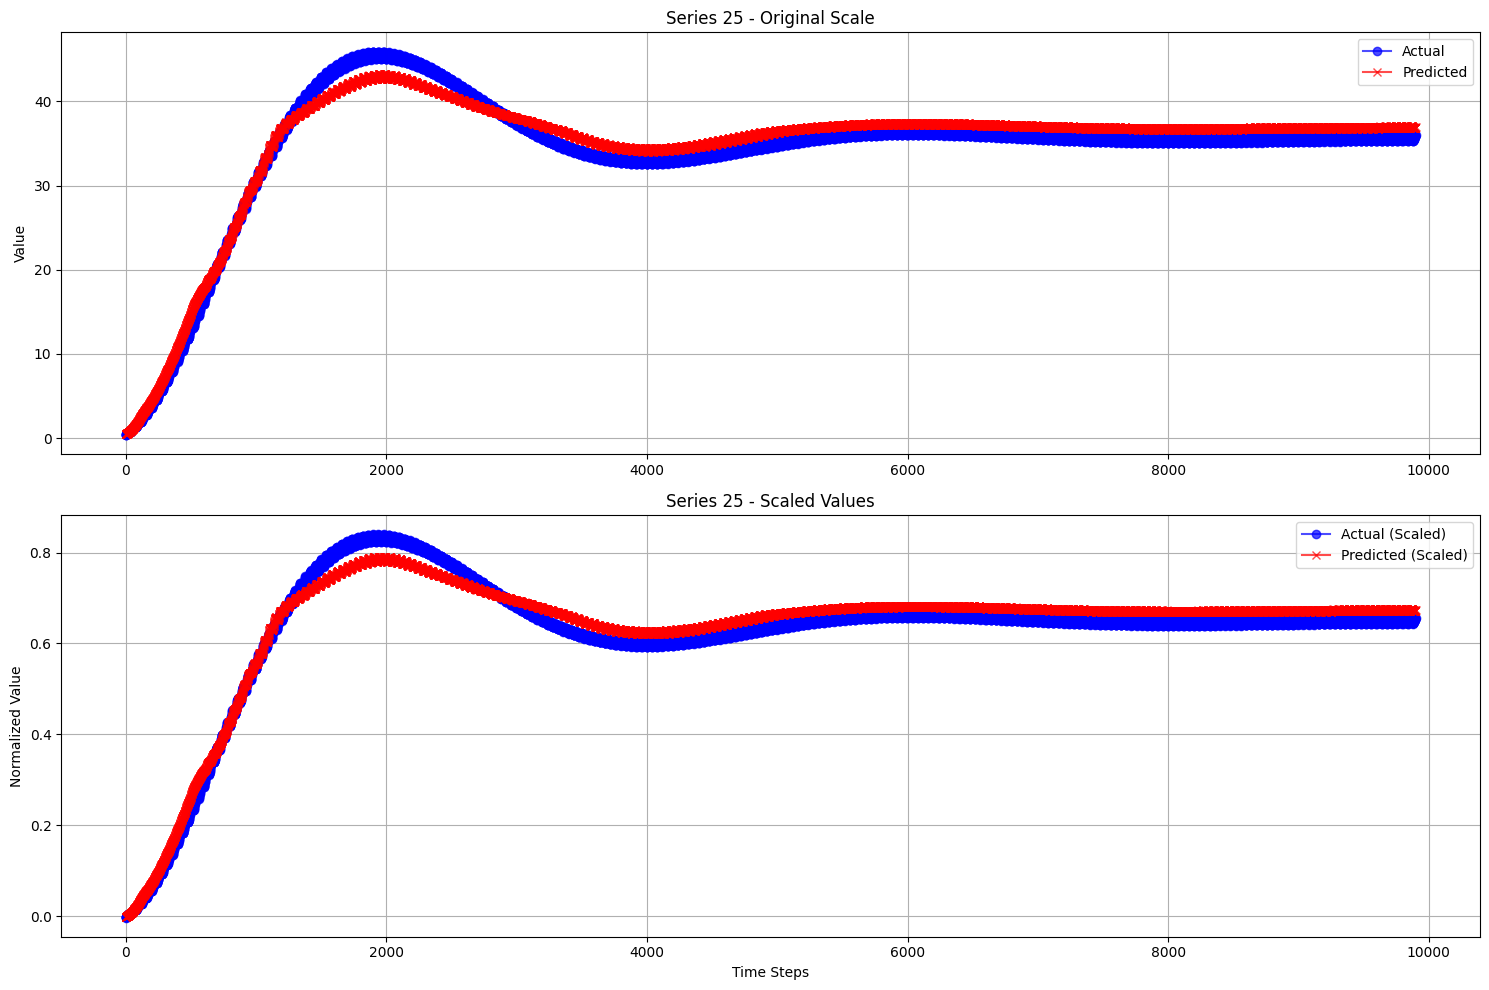

In [ ]:
# Select a specific series (change the ID as needed)
target_series_id = test_series[0]  # Using first test series as example

# Filter the results for this specific series
series_mask = (results_df['Series_ID'] == target_series_id)
series_data = results_df[series_mask].copy()

# Create the DataFrame with all values
series_comparison_df = pd.DataFrame({
    'Time_Step': np.arange(len(series_data)),  # Add time step index
    'Actual': series_data['Actual'],
    'Predicted': series_data['Predicted'],
    'Actual_Scaled': series_data['Actual_Scaled'],
    'Predicted_Scaled': series_data['Predicted_Scaled'],
    'Absolute_Error': np.abs(series_data['Actual'] - series_data['Predicted']),
    'Absolute_Error_Scaled': np.abs(series_data['Actual_Scaled'] - series_data['Predicted_Scaled']),
    'Percentage_Error': np.abs((series_data['Actual'] - series_data['Predicted']) / series_data['Actual']) * 100
})

# Calculate rolling errors (window of 3 steps)
window_size = 3
series_comparison_df['Rolling_MAE'] = series_comparison_df['Absolute_Error'].rolling(window=window_size).mean()
series_comparison_df['Rolling_MAE_Scaled'] = series_comparison_df['Absolute_Error_Scaled'].rolling(window=window_size).mean()

# Add some summary statistics as new rows
summary_stats = {
    'Time_Step': ['Stats'],
    'Actual': [series_comparison_df['Actual'].mean()],
    'Predicted': [series_comparison_df['Predicted'].mean()],
    'Actual_Scaled': [series_comparison_df['Actual_Scaled'].mean()],
    'Predicted_Scaled': [series_comparison_df['Predicted_Scaled'].mean()],
    'Absolute_Error': [series_comparison_df['Absolute_Error'].mean()],
    'Absolute_Error_Scaled': [series_comparison_df['Absolute_Error_Scaled'].mean()],
    'Percentage_Error': [series_comparison_df['Percentage_Error'].mean()],
    'Rolling_MAE': [np.nan],
    'Rolling_MAE_Scaled': [np.nan]
}

# Append summary stats to the DataFrame
series_comparison_df = pd.concat([
    series_comparison_df,
    pd.DataFrame(summary_stats)
], ignore_index=True)

# Format the DataFrame for better display
def format_float(x):
    if isinstance(x, (float, np.floating)):
        return round(x, 4)
    return x

series_comparison_df_formatted = series_comparison_df.applymap(format_float)

# Display the DataFrame
print(f"\nDetailed Comparison for Series {target_series_id}:")
display(series_comparison_df_formatted)

# Save to CSV
series_comparison_df.to_csv(f'series_{target_series_id}_comparison.csv', index=False)
print(f"\nData saved to 'series_{target_series_id}_comparison.csv'")

# Plotting both scales
plt.figure(figsize=(15, 10))

# Original scale plot
plt.subplot(2, 1, 1)
plt.plot(series_comparison_df['Time_Step'][:-1], series_comparison_df['Actual'][:-1],
         label='Actual', color='blue', alpha=0.7, marker='o')
plt.plot(series_comparison_df['Time_Step'][:-1], series_comparison_df['Predicted'][:-1],
         label='Predicted', color='red', alpha=0.7, marker='x')
plt.title(f'Series {target_series_id} - Original Scale')
plt.ylabel('Value')
plt.grid(True)
plt.legend()

# Scaled plot
plt.subplot(2, 1, 2)
plt.plot(series_comparison_df['Time_Step'][:-1], series_comparison_df['Actual_Scaled'][:-1],
         label='Actual (Scaled)', color='blue', alpha=0.7, marker='o')
plt.plot(series_comparison_df['Time_Step'][:-1], series_comparison_df['Predicted_Scaled'][:-1],
         label='Predicted (Scaled)', color='red', alpha=0.7, marker='x')
plt.title(f'Series {target_series_id} - Scaled Values')
plt.xlabel('Time Steps')
plt.ylabel('Normalized Value')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()